In [21]:
import pandas as pd

df = pd.read_csv("final_dataset.csv")

print(df.shape)
df.head()
df.info()





(54124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54124 entries, 0 to 54123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pitcher                   54124 non-null  int64  
 1   pitcher_name              54124 non-null  object 
 2   game_date                 54124 non-null  object 
 3   pitch_count               54124 non-null  int64  
 4   avg_velocity              54124 non-null  float64
 5   max_velocity              54124 non-null  float64
 6   min_velocity              54124 non-null  float64
 7   avg_spin_rate             53777 non-null  float64
 8   avg_extension             53799 non-null  float64
 9   avg_hmov                  54124 non-null  float64
 10  avg_vmov                  54124 non-null  float64
 11  n_pitch_types             54124 non-null  int64  
 12  season                    54124 non-null  int64  
 13  vel_drop_from_season_avg  54124 non-null  float64

In [22]:

df.isnull().sum().sort_values(ascending=False)

spin_drop                   347
avg_spin_rate               347
avg_extension               325
pitcher                       0
vel_drop_from_season_avg      0
age                           0
game_num_in_season            0
days_rest                     0
workload_14d                  0
workload_7d                   0
vel_trend                     0
vel_roll3                     0
n_pitch_types                 0
season                        0
pitcher_name                  0
avg_vmov                      0
avg_hmov                      0
min_velocity                  0
max_velocity                  0
avg_velocity                  0
pitch_count                   0
game_date                     0
injured_next_21d              0
dtype: int64

In [23]:
# rows where ANY of those columns are null
missing_rows = df[
    df['spin_drop'].isnull() | 
    df['avg_spin_rate'].isnull() | 
    df['avg_extension'].isnull()
]

# check injury distribution
missing_rows['injured_next_21d'].value_counts()

injured_next_21d
0    339
1      8
Name: count, dtype: int64

In [24]:
df['avg_spin_rate'] = df.groupby('pitcher')['avg_spin_rate'].transform(
    lambda x: x.fillna(x.median())
)

df['avg_extension'] = df.groupby('pitcher')['avg_extension'].transform(
    lambda x: x.fillna(x.median())
)

In [25]:
df['spin_drop'] = df.groupby('pitcher')['avg_spin_rate'].transform(
    lambda x: x.mean()
) - df['avg_spin_rate']

In [26]:
df['game_date'] = pd.to_datetime(df['game_date'])
df = df.sort_values(['pitcher', 'game_date'])

In [27]:
df.isnull().sum()

pitcher                     0
pitcher_name                0
game_date                   0
pitch_count                 0
avg_velocity                0
max_velocity                0
min_velocity                0
avg_spin_rate               0
avg_extension               0
avg_hmov                    0
avg_vmov                    0
n_pitch_types               0
season                      0
vel_drop_from_season_avg    0
vel_roll3                   0
vel_trend                   0
workload_7d                 0
workload_14d                0
days_rest                   0
game_num_in_season          0
spin_drop                   0
age                         0
injured_next_21d            0
dtype: int64

Text(0.5, 1.0, 'Injury vs Non-Injury Distribution')

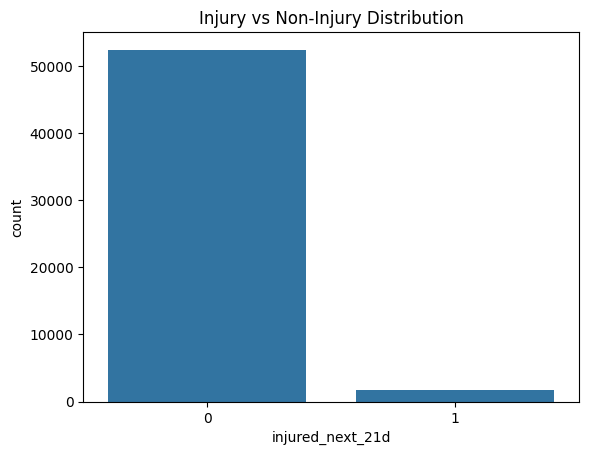

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='injured_next_21d', data=df)
plt.title("Injury vs Non-Injury Distribution")

<Axes: xlabel='injured_next_21d', ylabel='workload_7d'>

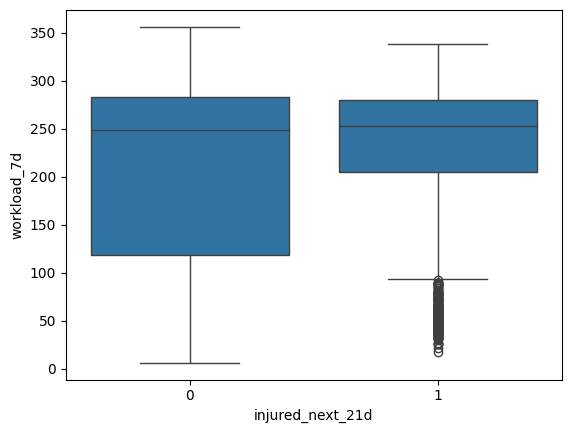

In [29]:
sns.boxplot(x='injured_next_21d', y='workload_7d', data=df)

injured group is shifted slightly higher , also non injury is wider spread having some low workload.  

<Axes: xlabel='injured_next_21d', ylabel='workload_14d'>

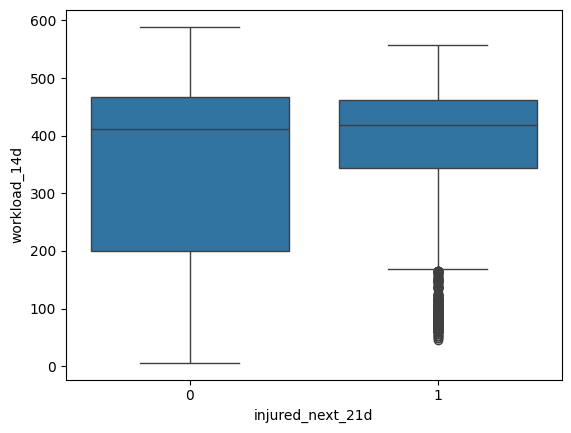

In [30]:
sns.boxplot(x='injured_next_21d', y='workload_14d', data=df)

same goes for this one  with the injury in next 21 days. 

<Axes: xlabel='injured_next_21d', ylabel='days_rest'>

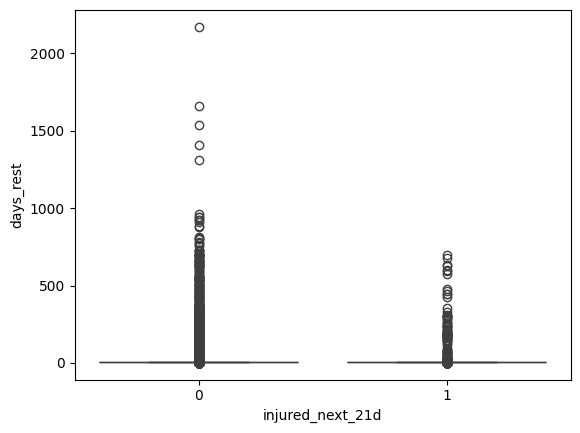

In [31]:
sns.boxplot(x='injured_next_21d', y='days_rest', data=df)

many of the outlier above 1000 days rest in the non injured players. 

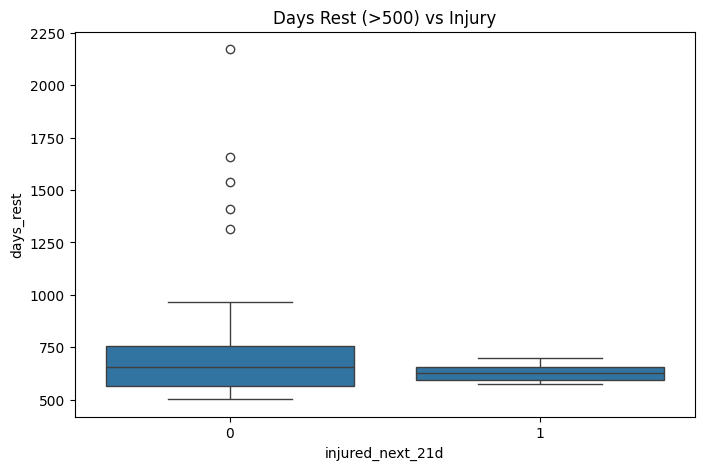

In [32]:
df_high_rest = df[df['days_rest'] > 500]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='injured_next_21d', y='days_rest', data=df_high_rest)
plt.title("Days Rest (>500) vs Injury")
plt.show()

non injury group has more wide spread rest days 
 while injury group is about 500-700 
 

<Axes: xlabel='injured_next_21d', ylabel='age'>

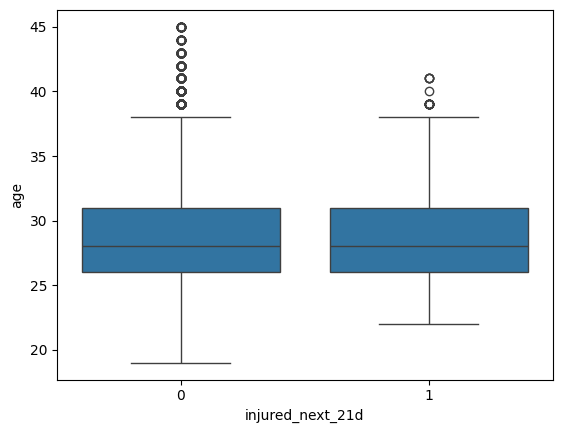

In [33]:
sns.boxplot(x='injured_next_21d', y='age', data=df)

<Axes: xlabel='workload_7d', ylabel='vel_drop_from_season_avg'>

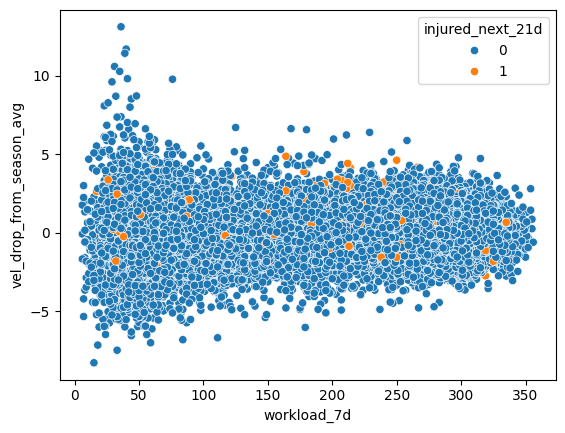

In [34]:
sns.scatterplot(
    x='workload_7d',
    y='vel_drop_from_season_avg',
    hue='injured_next_21d',
    data=df
)

highly unbalanced 

In [35]:
# separate classes
df_0 = df[df['injured_next_21d'] == 0].sample(n=2000, random_state=42)
df_1 = df[df['injured_next_21d'] == 1]

df_vis = pd.concat([df_0, df_1])

<Axes: xlabel='workload_7d', ylabel='vel_drop_from_season_avg'>

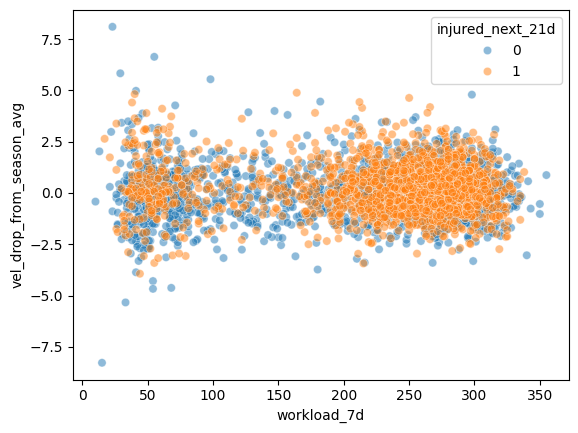

In [36]:
sns.scatterplot(
    x='workload_7d',
    y='vel_drop_from_season_avg',
    hue='injured_next_21d',
    data=df_vis,
    alpha=0.5
)

<Axes: xlabel='workload_7d', ylabel='vel_drop_from_season_avg'>

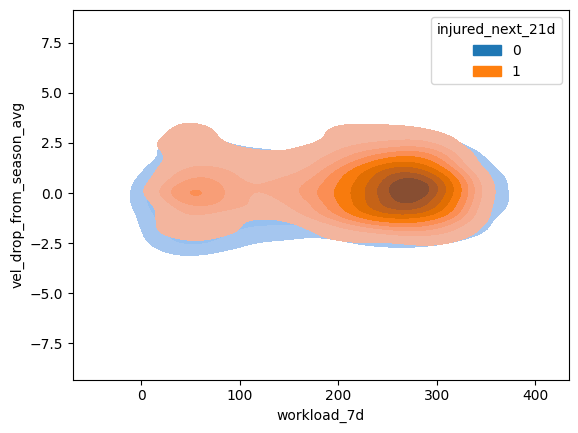

In [37]:
sns.kdeplot(
    data=df_vis,
    x='workload_7d',
    y='vel_drop_from_season_avg',
    hue='injured_next_21d',
    fill=True
)

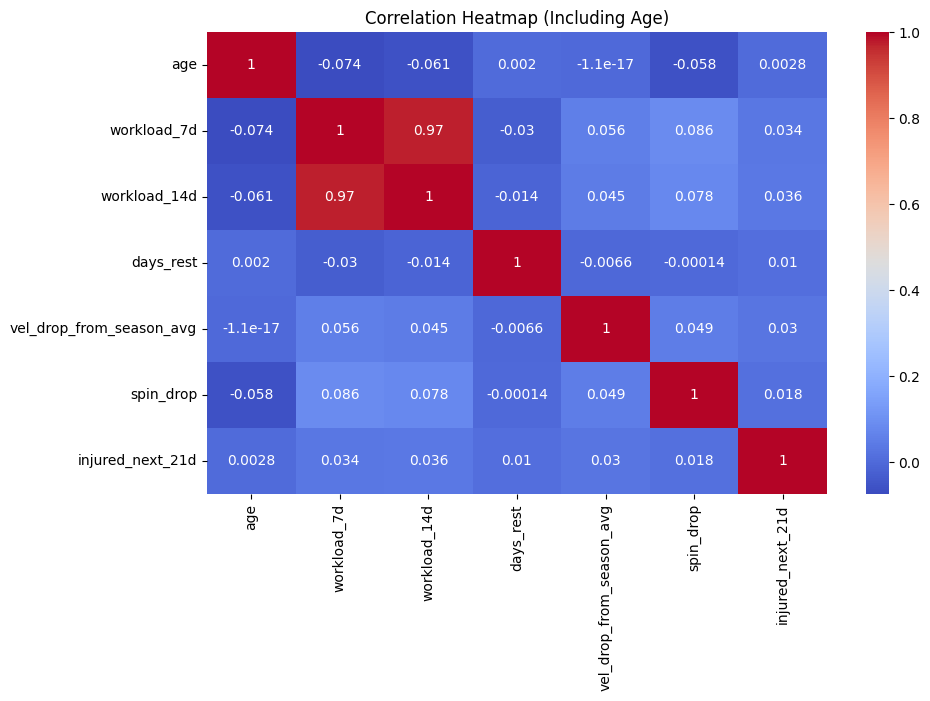

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    df[['age', 'workload_7d', 'workload_14d', 'days_rest',
        'vel_drop_from_season_avg', 'spin_drop', 'injured_next_21d']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap (Including Age)")
plt.show()

age shows neglible correlation with the injury occurrence indicating it is not a strong predictor in this dataset.

C:\Users\patel\AppData\Local\Temp\ipykernel_42452\1247600086.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  injury_rate = df.groupby('workload_bin')['injured_next_21d'].mean()


Text(0, 0.5, 'Injury Probability')

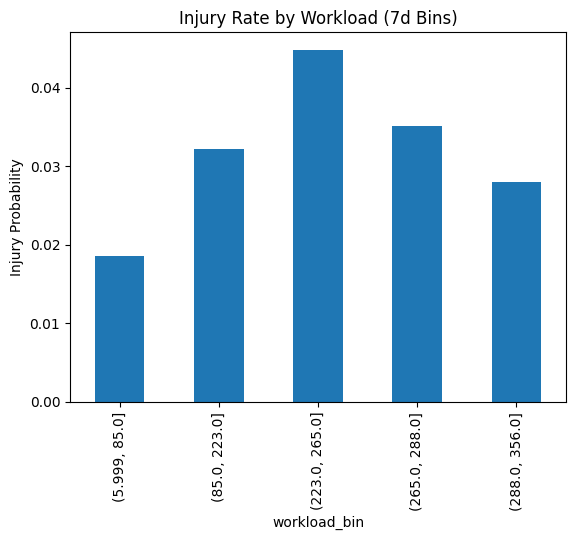

In [39]:
df['workload_bin'] = pd.qcut(df['workload_7d'], q=5)

injury_rate = df.groupby('workload_bin')['injured_next_21d'].mean()

injury_rate.plot(kind='bar')
plt.title("Injury Rate by Workload (7d Bins)")
plt.ylabel("Injury Probability")

C:\Users\patel\AppData\Local\Temp\ipykernel_42452\2955434535.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('vel_bin')['injured_next_21d'].mean().plot(kind='bar')


Text(0.5, 1.0, 'Injury Rate vs Velocity Drop')

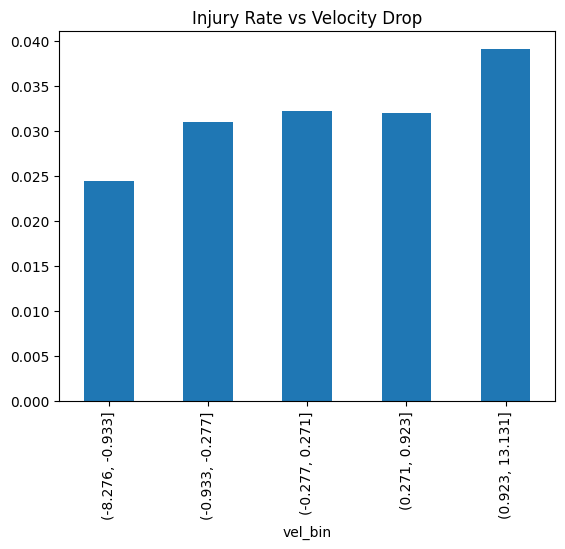

In [40]:
df['vel_bin'] = pd.qcut(df['vel_drop_from_season_avg'], q=5)

df.groupby('vel_bin')['injured_next_21d'].mean().plot(kind='bar')
plt.title("Injury Rate vs Velocity Drop")

C:\Users\patel\AppData\Local\Temp\ipykernel_42452\2182059403.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


Text(0.5, 1.0, 'Injury Risk Heatmap (Workload vs Velocity Drop)')

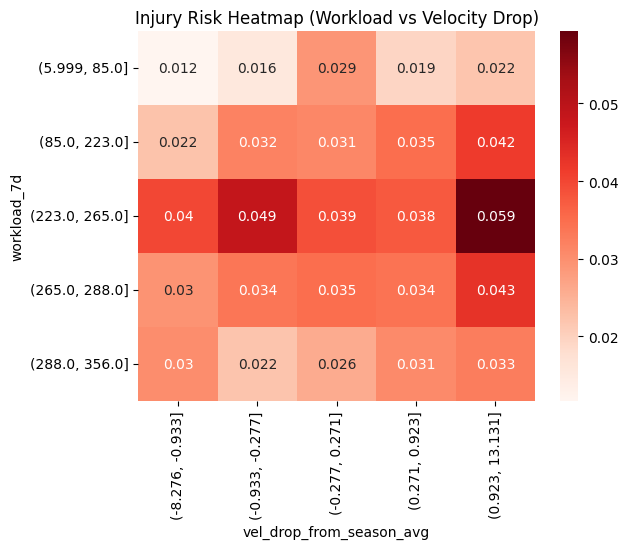

In [41]:
pivot = df.pivot_table(
    values='injured_next_21d',
    index=pd.qcut(df['workload_7d'], 5),
    columns=pd.qcut(df['vel_drop_from_season_avg'], 5),
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, cmap='Reds')
plt.title("Injury Risk Heatmap (Workload vs Velocity Drop)")

Text(0.5, 1.0, 'Pitcher Velocity Over Time')

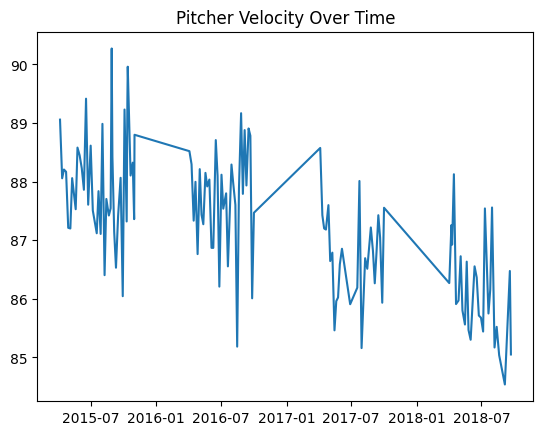

In [42]:
pitcher_id = df['pitcher'].iloc[0]

sample = df[df['pitcher'] == pitcher_id]

plt.plot(sample['game_date'], sample['avg_velocity'])
plt.title("Pitcher Velocity Over Time")